In [1]:
import pandas as pd
import seaborn as sns

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MultipleLocator
from matplotlib.ticker import MultipleLocator, FuncFormatter

/tmp/ipykernel_1643186/4130740166.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
import glob
import os
import pandas as pd

root = "/carnegie/nobackup/scratch/tbellagio/pang/pang_experiment/pangenomes"

pattern = os.path.join(root, "set_*", "output", "qc", "qc_allelicity_summary.*.tsv")
files = sorted(glob.glob(pattern))

print(f"Found {len(files)} qc_allelicity_summary files")
# print("\n".join(files[:5]))

dfs = []
for f in files:
    df = pd.read_csv(f, sep="\t")

    # set name is the suffix after qc_allelicity_summary.
    # e.g. qc_allelicity_summary.set_02_rep1.tsv -> set_02_rep1
    base = os.path.basename(f)
    set_name = base.replace("qc_allelicity_summary.", "").replace(".tsv", "")
    df["set"] = set_name

    # also store absolute path (useful for debugging)
    df["source_path"] = f

    dfs.append(df)

allelicity_all = pd.concat(dfs, ignore_index=True)

# optional: reorder cols nicely
cols = ["set", "vcf", "total_records", "biallelic_records", "multiallelic_records", "max_ALTs", "total_ALT_alleles", "source_path"]
allelicity_all = allelicity_all[cols]


Found 17 qc_allelicity_summary files


In [3]:
allelicity_all

,set,vcf,total_records,biallelic_records,multiallelic_records,max_ALTs,total_ALT_alleles,source_path
0,set_02_rep1,set_02_rep1.deconstruct.top.vcf.gz,786718,786691,27,2,786745,/carnegie/nobackup/scratch/tbellagio/pang/pang...
1,set_02_rep1,set_02_rep1.deconstruct.all_snarls.vcf.gz,802466,802439,27,2,802493,/carnegie/nobackup/scratch/tbellagio/pang/pang...
2,set_02_rep1,set_02_rep1.vcf.gz,800672,800672,0,1,800672,/carnegie/nobackup/scratch/tbellagio/pang/pang...
3,set_02_rep2,set_02_rep2.deconstruct.top.vcf.gz,850247,850228,19,2,850266,/carnegie/nobackup/scratch/tbellagio/pang/pang...
4,set_02_rep2,set_02_rep2.deconstruct.all_snarls.vcf.gz,868177,868158,19,2,868196,/carnegie/nobackup/scratch/tbellagio/pang/pang...
5,set_02_rep2,set_02_rep2.vcf.gz,866944,866944,0,1,866944,/carnegie/nobackup/scratch/tbellagio/pang/pang...
6,set_02_rep3,set_02_rep3.deconstruct.top.vcf.gz,905508,905508,0,1,905508,/carnegie/nobackup/scratch/tbellagio/pang/pang...
7,set_02_rep3,set_02_rep3.deconstruct.all_snarls.vcf.gz,913913,913913,0,1,913913,/carnegie/nobackup/scratch/tbellagio/pang/pang...
8,set_02_rep3,set_02_rep3.vcf.gz,911964,911964,0,1,911964,/carnegie/nobackup/scratch/tbellagio/pang/pang...
9,set_05_rep1,set_05_rep1.deconstruct.top.vcf.gz,1820573,1716736,103837,11,1948483,/carnegie/nobackup/scratch/tbellagio/pang/pang...


In [4]:
base_path = '/carnegie/nobackup/scratch/tbellagio/pang/pang_experiment/pangenomes/'

snarls_top = pd.read_csv(base_path + 'set_05_rep1/output/qc/qc_sizes_biallelic.set_05_rep1.deconstruct.top.tsv', sep = '\t')

In [5]:
snarls_top['is_conflict'].value_counts()

is_conflict
0    1947171
1       1312
Name: count, dtype: int64

In [7]:
snarls_top

,chrom,pos,id,class,size_signed,size_bp,is_conflict
0,TAIR10#0#Chr1,1,>1>159,INS,2163,2163,0
1,TAIR10#0#Chr1,1,>1>159,INS,3014,3014,0
2,TAIR10#0#Chr1,1,>1>159,INS,3966,3966,0
3,TAIR10#0#Chr1,59,>159>161,INS,82,82,0
4,TAIR10#0#Chr1,62,>161>164,SNP,0,0,0
...,...,...,...,...,...,...,...
1948478,TAIR10#0#Chr5,26974567,>6642189>6642192,SNP,0,0,0
1948479,TAIR10#0#Chr5,26974598,>6642192>6642194,INS,14,14,0
1948480,TAIR10#0#Chr5,26974603,>6642194>6642197,SNP,0,0,0
1948481,TAIR10#0#Chr5,26974605,>6642197>6642200,SNP,0,0,0


In [4]:
import pandas as pd
from pathlib import Path

def drop_conflicts(df: pd.DataFrame) -> tuple[pd.DataFrame, int]:
    """
    If a CONFLICT column exists, drop rows where it is non-empty/non-null.
    Returns (filtered_df, n_dropped).
    """
    if "is_conflict" not in df.columns:
        return df, 0

    c = df["is_conflict"]

    # treat 0 as no-conflict; anything else = conflict
    no_conflict = (c.astype(str).str.strip() == "0")

    n_dropped = int((~no_conflict).sum())
    return df.loc[no_conflict].copy(), n_dropped


def summarize_qc_sizes(df: pd.DataFrame, label: str = None) -> pd.Series:
    required = {"class", "size_signed"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    s = df["size_signed"].astype("int64")
    cls = df["class"].astype("string")

    out = {}
    if label is not None:
        out["label"] = label

    out["n_total"] = int(len(df))

    class_counts = cls.value_counts(dropna=False)
    for k, v in class_counts.items():
        out[f"class_count_{k}"] = int(v)

    out["n_size_0"] = int((s == 0).sum())
    out["n_small_ins_1_40"]  = int(((s >= 1) & (s <= 40)).sum())
    out["n_small_del_1_m40"] = int(((s <= -1) & (s >= -40)).sum())
    out["n_mid_ins_41_10k"]  = int(((s >= 41) & (s <= 10_000)).sum())
    out["n_mid_del_41_m10k"] = int(((s <= -41) & (s >= -10_000)).sum())
    out["n_large_ins_10k"]   = int((s > 10_000).sum())
    out["n_large_del_10k"]   = int((s < -10_000).sum())

    return pd.Series(out)


base_path = Path("/carnegie/nobackup/scratch/tbellagio/pang/pang_experiment/pangenomes")
qc_files = sorted(base_path.glob("set_*/output/qc/qc_sizes_biallelic.*.tsv"))
print(f"Found {len(qc_files)} qc_sizes files")

files_by_set = {}
for f in qc_files:
    setname = f.parts[-4]
    files_by_set.setdefault(setname, []).append(f)

for setname, files in files_by_set.items():
    rows = []
    for f in files:
        label = f.stem.replace("qc_sizes_biallelic.", "")
        df = pd.read_csv(f, sep="\t")

        df_filt, n_drop = drop_conflicts(df)
        s = summarize_qc_sizes(df_filt, label=label)

        # add conflict bookkeeping columns
        s["n_conflict_dropped"] = n_drop
        s["n_before_filter"] = int(len(df))

        rows.append(s)

    summary = pd.DataFrame(rows).fillna(0)

    outdir = base_path / setname / "output" / "qc"
    outpath = outdir / "qc_sizes_summary.tsv"
    summary.to_csv(outpath, sep="\t", index=False)

    print(f"Wrote {len(files)} rows -> {outpath}")


Found 51 qc_sizes files
Wrote 3 rows -> /carnegie/nobackup/scratch/tbellagio/pang/pang_experiment/pangenomes/set_02_rep1/output/qc/qc_sizes_summary.tsv
Wrote 3 rows -> /carnegie/nobackup/scratch/tbellagio/pang/pang_experiment/pangenomes/set_02_rep2/output/qc/qc_sizes_summary.tsv
Wrote 3 rows -> /carnegie/nobackup/scratch/tbellagio/pang/pang_experiment/pangenomes/set_02_rep3/output/qc/qc_sizes_summary.tsv
Wrote 3 rows -> /carnegie/nobackup/scratch/tbellagio/pang/pang_experiment/pangenomes/set_05_rep1/output/qc/qc_sizes_summary.tsv
Wrote 3 rows -> /carnegie/nobackup/scratch/tbellagio/pang/pang_experiment/pangenomes/set_05_rep2/output/qc/qc_sizes_summary.tsv
Wrote 3 rows -> /carnegie/nobackup/scratch/tbellagio/pang/pang_experiment/pangenomes/set_05_rep3/output/qc/qc_sizes_summary.tsv
Wrote 3 rows -> /carnegie/nobackup/scratch/tbellagio/pang/pang_experiment/pangenomes/set_10_rep1/output/qc/qc_sizes_summary.tsv
Wrote 3 rows -> /carnegie/nobackup/scratch/tbellagio/pang/pang_experiment/pangen

In [5]:
pd.read_csv('/carnegie/nobackup/scratch/tbellagio/pang/pang_experiment/pangenomes/set_02_rep1/output/qc/qc_sizes_summary.tsv',sep = '\t')

,label,n_total,class_count_SNP,class_count_INS,class_count_DEL,class_count_MNP,n_size_0,n_small_ins_1_40,n_small_del_1_m40,n_mid_ins_41_10k,n_mid_del_41_m10k,n_large_ins_10k,n_large_del_10k,n_conflict_dropped,n_before_filter
0,set_02_rep1.deconstruct.all_snarls,801890,620868,72160,70974,37888,658756,67681,66594,4360,4284,119,96,603,802493
1,set_02_rep1.deconstruct.top,786142,608045,71162,69928,37007,645052,66781,65663,4266,4172,115,93,603,786745
2,set_02_rep1,800672,619976,72061,70899,37736,657712,67605,66534,4337,4269,119,96,0,800672


In [18]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

base = Path("/carnegie/nobackup/scratch/tbellagio/pang/pang_experiment/pangenomes")

# --- load summaries ---
summary_files = sorted(base.glob("set_*/output/qc/qc_sizes_summary.tsv"))
dfs = []
for f in summary_files:
    setname = f.parts[-4]
    df = pd.read_csv(f, sep="\t")
    df["setname"] = setname
    dfs.append(df)
all_sum = pd.concat(dfs, ignore_index=True)

In [19]:
base = all_sum[~all_sum["label"].astype(str).str.contains(r"\.deconstruct\.top$", regex=True)].copy()
base = base[~base["label"].astype(str).str.contains(r".all", regex=True)].copy()


In [20]:
base

,label,n_total,class_count_SNP,class_count_INS,class_count_DEL,class_count_MNP,n_size_0,n_small_ins_1_40,n_small_del_1_m40,n_mid_ins_41_10k,n_mid_del_41_m10k,n_large_ins_10k,n_large_del_10k,n_conflict_dropped,n_before_filter,setname
2,set_02_rep1,800672,619976,72061,70899,37736,657712,67605,66534,4337,4269,119,96,0,800672,set_02_rep1
5,set_02_rep2,866944,668827,78418,78111,41588,710415,73667,73418,4635,4579,116,114,0,866944,set_02_rep2
8,set_02_rep3,911964,706228,80903,81083,43750,749978,76020,76131,4773,4822,110,130,0,911964,set_02_rep3
11,set_05_rep1,2001076,1434339,195850,198898,171989,1606328,179542,186554,15860,11976,448,368,111,2001187,set_05_rep1
14,set_05_rep2,2050055,1454573,199128,205486,190868,1645441,182047,192614,16622,12506,459,366,15,2050070,set_05_rep2
17,set_05_rep3,1854943,1324814,180237,183571,166321,1491135,164681,171894,15111,11332,445,345,21,1854964,set_05_rep3
20,set_10_rep1,2628943,1785577,275048,277508,290810,2076387,245214,258348,28763,18421,1071,739,464,2629407,set_10_rep1
23,set_10_rep2,2626857,1794563,275285,275017,281992,2076555,246047,256223,28197,18072,1041,722,229,2627086,set_10_rep2
26,set_10_rep3,2543746,1738249,265883,266892,272722,2010971,237460,248401,27442,17781,981,710,199,2543945,set_10_rep3
29,set_15_rep1,3059280,2019086,334313,331552,374329,2393415,293876,307173,38920,23244,1517,1135,273,3059553,set_15_rep1


In [21]:

# parse set size + rep; set_all = 69
m = base["setname"].str.extract(r"set_(\d+|all)_rep(\d+)")
base["set_size_raw"] = m[0]
base["rep"] = m[1].astype(int)
base["set_size"] = pd.to_numeric(base["set_size_raw"], errors="coerce")
base.loc[base["set_size_raw"] == "all", "set_size"] = 69
base["set_size"] = base["set_size"].astype(int)

components = [
    "class_count_SNP",
    "class_count_MNP",
    "n_small_ins_1_40",
    "n_mid_ins_41_10k",
    "n_large_ins_10k",
    "n_small_del_1_m40",
    "n_mid_del_41_m10k",
    "n_large_del_10k",
]
for c in components:
    if c not in base.columns:
        base[c] = 0

# mean across reps per set size
agg = base.groupby("set_size")[components].mean().sort_index()

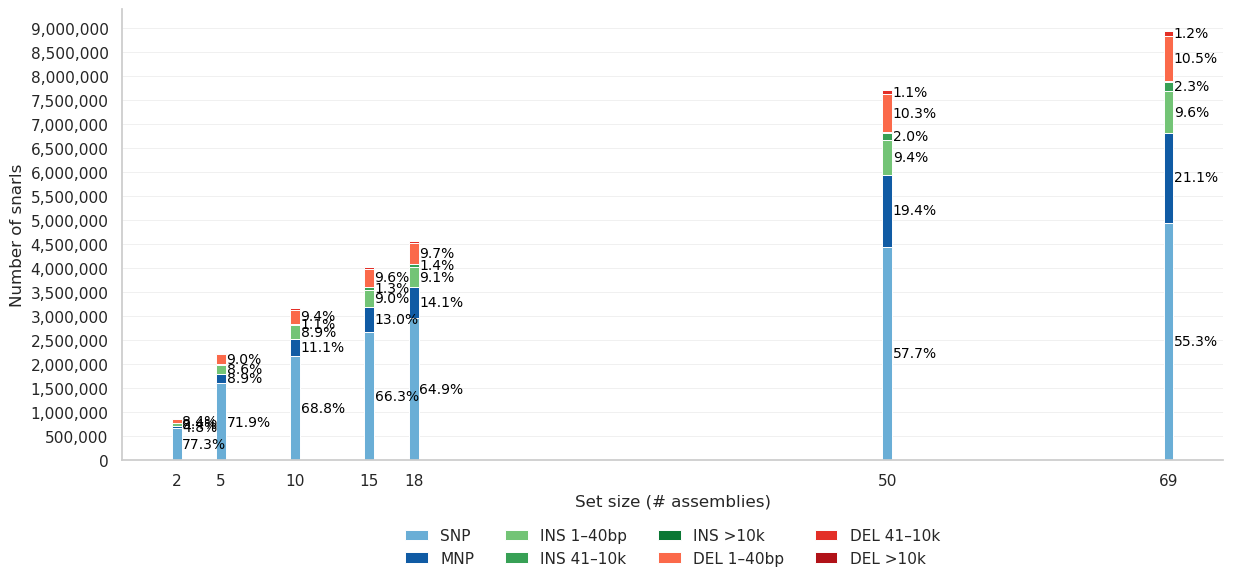

In [74]:


sns.set_theme(style="whitegrid", context="notebook")

components = [
    "class_count_SNP",
    "class_count_MNP",
    "n_small_ins_1_40",
    "n_mid_ins_41_10k",
    "n_large_ins_10k",
    "n_small_del_1_m40",
    "n_mid_del_41_m10k",
    "n_large_del_10k",
]

pretty = {
    "class_count_SNP": "SNP",
    "class_count_MNP": "MNP",
    "n_small_ins_1_40": "INS 1–40bp",
    "n_mid_ins_41_10k": "INS 41–10k",
    "n_large_ins_10k": "INS >10k",
    "n_small_del_1_m40": "DEL 1–40bp",
    "n_mid_del_41_m10k": "DEL 41–10k",
    "n_large_del_10k": "DEL >10k",
}

blues  = sns.color_palette("Blues",  5)
greens = sns.color_palette("Greens", 5)
reds   = sns.color_palette("Reds",   5)

colors = {
    "class_count_SNP": blues[2],
    "class_count_MNP": blues[4],
    "n_small_ins_1_40": greens[2],
    "n_mid_ins_41_10k": greens[3],
    "n_large_ins_10k": greens[4],
    "n_small_del_1_m40": reds[2],
    "n_mid_del_41_m10k": reds[3],
    "n_large_del_10k": reds[4],
}

# Fill missing cols with 0
for c in components:
    if c not in agg.columns:
        agg[c] = 0

agg_plot = agg[components].copy().sort_index()
x = agg_plot.index.values.astype(float)
totals = agg_plot.sum(axis=1).values

# ✅ More separation: narrower bars
bar_width = 2.0   # was 2.6; reduce for more gap (try 1.6–2.2)

fig, ax = plt.subplots(figsize=(12.5, 6))

bottom = np.zeros(len(agg_plot))


x_raw = agg_plot.index.values.astype(float)
stretch = 3
x = x_raw * stretch

# draw stacked bars
for c in components:
    vals = agg_plot[c].values
    ax.bar(
        x, vals, bottom=bottom, width=bar_width,
        color=colors[c],
        edgecolor="white", linewidth=0.7,
        label=pretty.get(c, c),
        align="center"
    )
    bottom += vals

# ---- percent labels next to the bars (right side) ----
min_pct_label = 0.01  # 1%
x_offset = 0.1     # ✅ small horizontal offset beyond bar edge (in x units)
fontsize = 10

bottom = np.zeros(len(agg_plot))
for c in components:
    vals = agg_plot[c].values
    for i, v in enumerate(vals):
        if v <= 0 or totals[i] <= 0:
            continue
        pct = v / totals[i]
        if pct < min_pct_label:
            continue

        # ✅ label just to the right of the bar segment
        x_text = x[i] + (bar_width / 2) + x_offset
        y_text = bottom[i] + v / 2

        ax.text(
            x_text, y_text,
            f"{pct*100:.1f}%",
            ha="left", va="center",
            fontsize=fontsize,
            color="black",
            clip_on=False
        )
    bottom += vals

# axes formatting
ax.set_xlabel("Set size (# assemblies)")
ax.set_ylabel("Number of snarls")
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{int(y):,}"))

ax.set_xticks(x)
ax.set_xticklabels([str(int(v)) for v in x_raw])

# grid control
step = 500_000
ax.yaxis.set_major_locator(MultipleLocator(step))
ax.grid(True, axis="y", which="major", linewidth=0.6, alpha=0.35)
ax.grid(False, axis="x")

# ✅ give extra right margin so text isn't cut off
xmin, xmax = ax.get_xlim()
ax.set_xlim(xmin, xmax)   # increase if labels still clip

# legend placement
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),  # (x center, a bit below the axes)
    ncol=4,                       # adjust columns to taste
    frameon=False,
    title="",
    handlelength=1.5
)

sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('snarls_quant_top.png')
plt.show()


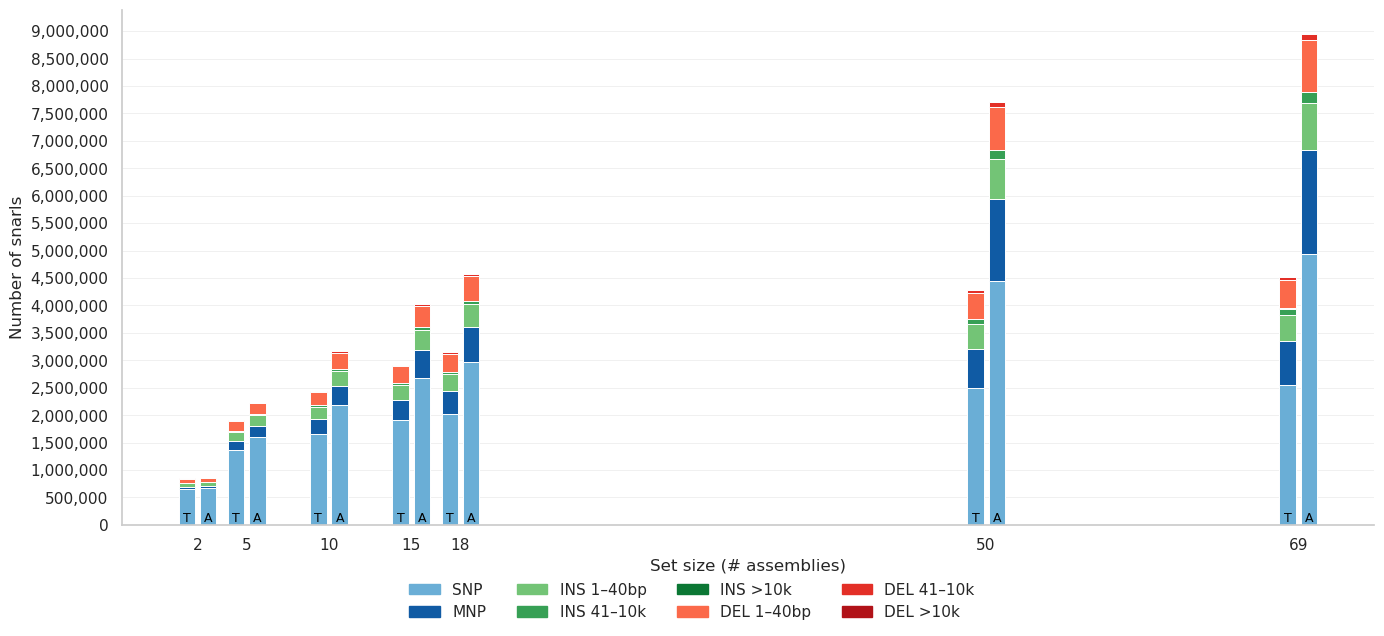

In [75]:
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MultipleLocator

base = Path("/carnegie/nobackup/scratch/tbellagio/pang/pang_experiment/pangenomes")

# --- load summaries ---
summary_files = sorted(base.glob("set_*/output/qc/qc_sizes_summary.tsv"))
dfs = []
for f in summary_files:
    setname = f.parts[-4]
    df = pd.read_csv(f, sep="\t")
    df["setname"] = setname
    dfs.append(df)
all_sum = pd.concat(dfs, ignore_index=True)

sns.set_theme(style="whitegrid", context="notebook")

components = [
    "class_count_SNP",
    "class_count_MNP",
    "n_small_ins_1_40",
    "n_mid_ins_41_10k",
    "n_large_ins_10k",
    "n_small_del_1_m40",
    "n_mid_del_41_m10k",
    "n_large_del_10k",
]

pretty = {
    "class_count_SNP": "SNP",
    "class_count_MNP": "MNP",
    "n_small_ins_1_40": "INS 1–40bp",
    "n_mid_ins_41_10k": "INS 41–10k",
    "n_large_ins_10k": "INS >10k",
    "n_small_del_1_m40": "DEL 1–40bp",
    "n_mid_del_41_m10k": "DEL 41–10k",
    "n_large_del_10k": "DEL >10k",
}

# seaborn-ish shades
blues  = sns.color_palette("Blues",  5)
greens = sns.color_palette("Greens", 5)
reds   = sns.color_palette("Reds",   5)

colors = {
    "class_count_SNP": blues[2],
    "class_count_MNP": blues[4],
    "n_small_ins_1_40": greens[2],
    "n_mid_ins_41_10k": greens[3],
    "n_large_ins_10k": greens[4],
    "n_small_del_1_m40": reds[2],
    "n_mid_del_41_m10k": reds[3],
    "n_large_del_10k": reds[4],
}

def prep_mode(df_all: pd.DataFrame, mode: str) -> pd.DataFrame:
    """
    mode: "top" or "all_snarls"
    Returns agg df indexed by set_size with mean across reps.
    """
    pat = r"\.deconstruct\.top$" if mode == "top" else r"\.deconstruct\.all_snarls$"
    df = df_all[df_all["label"].astype(str).str.contains(pat, regex=True)].copy()

    m = df["setname"].str.extract(r"set_(\d+|all)_rep(\d+)")
    df["set_size_raw"] = m[0]
    df["rep"] = m[1].astype(int)

    df["set_size"] = pd.to_numeric(df["set_size_raw"], errors="coerce")
    df.loc[df["set_size_raw"] == "all", "set_size"] = 69
    df["set_size"] = df["set_size"].astype(int)

    for c in components:
        if c not in df.columns:
            df[c] = 0

    return df.groupby("set_size")[components].mean()

# compute mean across reps
agg_top = prep_mode(all_sum, "top")
agg_all = prep_mode(all_sum, "all_snarls")

# union of x categories (set sizes)
set_sizes = sorted(set(agg_top.index).union(set(agg_all.index)))

# reindex so both have all set sizes (missing -> 0)
agg_top = agg_top.reindex(set_sizes, fill_value=0)
agg_all = agg_all.reindex(set_sizes, fill_value=0)

# ---- grouped positions using numeric spacing ----
# keep x positions proportional to set size, but offset the two bars left/right
x = np.array(set_sizes, dtype=float)

# bar widths in x-units (gap smallest usually 3 between 2 and 5)
bar_width = 1.0          # width of each of the two bars
bar_sep = 0.65           # half-distance between the two bar centers within a group

x_top = x - bar_sep
x_all = x + bar_sep

fig, ax = plt.subplots(figsize=(14, 6))

# stacked bar helper
def draw_stacked(ax, x_positions, agg_plot, bar_label):
    bottom = np.zeros(len(agg_plot))
    for c in components:
        vals = agg_plot[c].values
        ax.bar(
            x_positions, vals, bottom=bottom, width=bar_width,
            color=colors[c],
            edgecolor="white", linewidth=0.7,
            align="center"
        )
        bottom += vals
    # add an invisible handle for the bar_label (top vs all) if you want separate legend
    ax.bar([], [], color="none", label=bar_label)

# draw both stacks
draw_stacked(ax, x_top, agg_top[components], "top")
draw_stacked(ax, x_all, agg_all[components], "all")

# ---- axes ----
ax.set_xlabel("Set size (# assemblies)")
ax.set_ylabel("Number of snarls")
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{int(y):,}"))
ax.set_xticks(x)
ax.set_xticklabels([str(int(v)) for v in x])

# grid every 500k
step = 500_000
ax.yaxis.set_major_locator(MultipleLocator(step))
ax.grid(True, axis="y", which="major", linewidth=0.6, alpha=0.35)
ax.grid(False, axis="x")
sns.despine(ax=ax)

# ---- legend(s) ----
# 1) legend for stack colors (components)
handles_comp = [plt.Rectangle((0,0),1,1, color=colors[c]) for c in components]
labels_comp = [pretty.get(c, c) for c in components]

# 2) legend for top vs all (pattern)
handles_mode = [
    plt.Rectangle((0,0),1,1, facecolor="lightgray", edgecolor="black"),
    plt.Rectangle((0,0),1,1, facecolor="darkgray", edgecolor="black"),
]
labels_mode = ["top", "all"]
# Instead of different colors for mode (we kept same stack colors),
# we can annotate with text above each bar group:
for i, s in enumerate(set_sizes):
    ax.text(x_top[i], 0, "T", ha="center", va="bottom", fontsize=9, color="black")
    ax.text(x_all[i], 0, "A", ha="center", va="bottom", fontsize=9, color="black")

# Put component legend at bottom
fig.legend(
    handles_comp, labels_comp,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.07),
    ncol=4,
    frameon=False,
)

plt.tight_layout()
plt.savefig('snarls_quant_top_vs_all.png')

plt.show()


In [83]:
import pandas as pd

path = "/carnegie/nobackup/scratch/tbellagio/pang/pang_experiment/pangenomes/set_all_rep1/output/qc/qc_sizes_summary.tsv"
df = pd.read_csv(path, sep="\t")

metrics = [
    "class_count_SNP",
    "class_count_MNP",
    "n_small_ins_1_40",
    "n_small_del_1_m40",
    "n_mid_ins_41_10k",
    "n_mid_del_41_m10k",
    "n_large_ins_10k",
    "n_large_del_10k",
    "n_size_0",
]

for m in metrics:
    if m in df.columns:
        df[f"{m}_pct"] = (df[m] / df["n_total"]) * 100

pct_cols = [c for c in df.columns if c.endswith("_pct")]
df[pct_cols] = df[pct_cols].round(2)

print(pct_cols)
df


['class_count_SNP_pct', 'class_count_MNP_pct', 'n_small_ins_1_40_pct', 'n_small_del_1_m40_pct', 'n_mid_ins_41_10k_pct', 'n_mid_del_41_m10k_pct', 'n_large_ins_10k_pct', 'n_large_del_10k_pct', 'n_size_0_pct']


,label,n_total,class_count_SNP,class_count_MNP,class_count_INS,class_count_DEL,n_size_0,n_small_ins_1_40,n_small_del_1_m40,n_mid_ins_41_10k,...,n_before_filter,class_count_SNP_pct,class_count_MNP_pct,n_small_ins_1_40_pct,n_small_del_1_m40_pct,n_mid_ins_41_10k_pct,n_mid_del_41_m10k_pct,n_large_ins_10k_pct,n_large_del_10k_pct,n_size_0_pct
0,set_all_rep1.deconstruct.all_snarls,8943343,4941876,1883861,1067004,1050602,6825737,857320,939353,201714,...,8966805,55.26,21.06,9.59,10.50,2.26,1.19,0.09,0.06,76.32
1,set_all_rep1.deconstruct.top,4525850,2557688,788787,599264,580111,3346475,487174,521726,107730,...,4526509,56.51,17.43,10.76,11.53,2.38,1.22,0.10,0.07,73.94


In [93]:
import pandas as pd

path = "/carnegie/nobackup/scratch/tbellagio/pang/pang_experiment/pangenomes/set_all_rep1/output/qc/qc_sizes_summary.tsv"
df = pd.read_csv(path, sep="\t")

# split the two rows
all_row = df[df["label"].str.contains(r"\.deconstruct\.all_snarls$")].iloc[0]
top_row = df[df["label"].str.contains(r"\.deconstruct\.top$")].iloc[0]

# choose metrics you want in the output
metrics = [
    "n_total",
    "class_count_SNP",
    "class_count_MNP",
    "n_size_0",
    "n_small_ins_1_40",
    "n_small_del_1_m40",
    "n_mid_ins_41_10k",
    "n_mid_del_41_m10k",
    "n_large_ins_10k",
    "n_large_del_10k",
    "n_conflict_dropped",
    "n_before_filter",
]

# counts
all_n = all_row[metrics].astype("float64")
top_n = top_row[metrics].astype("float64")

# percents (relative to n_total); keep n_total itself as NA (or 100 if you prefer)
all_pct = (all_n / all_row["n_total"]) * 100
top_pct = (top_n / top_row["n_total"]) * 100
all_pct.loc["n_total"] = pd.NA
top_pct.loc["n_total"] = pd.NA

# make the 4-column table
wide4 = pd.DataFrame({
    "metric": metrics,
    "all_snarls_n": all_n.values.astype(int),
    "all_snarls_pct": all_pct.round(2).values,
    "top_n": top_n.values.astype(int),
    "top_pct": top_pct.round(2).values,
})

wide4


,metric,all_snarls_n,all_snarls_pct,top_n,top_pct
0,n_total,8943343,NaN,4525850,NaN
1,class_count_SNP,4941876,55.26,2557688,56.51
2,class_count_MNP,1883861,21.06,788787,17.43
3,n_size_0,6825737,76.32,3346475,73.94
4,n_small_ins_1_40,857320,9.59,487174,10.76
5,n_small_del_1_m40,939353,10.50,521726,11.53
6,n_mid_ins_41_10k,201714,2.26,107730,2.38
7,n_mid_del_41_m10k,106261,1.19,55010,1.22
8,n_large_ins_10k,7970,0.09,4360,0.10
9,n_large_del_10k,4988,0.06,3375,0.07


In [94]:
4941876/ 8943343

0.552575921554166

In [86]:
import pandas as pd
import numpy as np

path = "/carnegie/nobackup/scratch/tbellagio/pang/pang_experiment/pangenomes/set_all_rep1/output/qc/qc_sizes_summary.tsv"
df = pd.read_csv(path, sep="\t")

metrics = [
    "class_count_SNP",
    "class_count_MNP",
    "n_small_ins_1_40",
    "n_small_del_1_m40",
    "n_mid_ins_41_10k",
    "n_mid_del_41_m10k",
    "n_large_ins_10k",
    "n_large_del_10k",
    "n_size_0",
]

def add_pct_columns(df_in: pd.DataFrame) -> pd.DataFrame:
    df2 = df_in.copy()

    # Case A: metrics are columns
    if "n_total" in df2.columns and any(m in df2.columns for m in metrics):
        for m in metrics:
            if m in df2.columns:
                df2[f"{m}_pct"] = (df2[m] / df2["n_total"]) * 100
        pct_cols = [c for c in df2.columns if c.endswith("_pct")]
        df2[pct_cols] = df2[pct_cols].round(2)
        return df2

    # Case B: metrics are in the index (metrics-as-rows)
    # Try: use first column as label and transpose into metrics-as-columns
    if "label" in df2.columns:
        df_t = df2.set_index("label").T
    else:
        df_t = df2.T

    # coerce numeric where possible
    df_t = df_t.apply(pd.to_numeric, errors="coerce")

    # now df_t should have n_total + metrics as columns
    if "n_total" not in df_t.columns:
        raise ValueError("Could not find n_total after transposing; print df.head() and df.columns to debug.")

    for m in metrics:
        if m in df_t.columns:
            df_t[f"{m}_pct"] = (df_t[m] / df_t["n_total"]) * 100

    pct_cols = [c for c in df_t.columns if c.endswith("_pct")]
    df_t[pct_cols] = df_t[pct_cols].round(2)

    # return in the same orientation as df_t (rows = modes)
    return df_t.reset_index(drop=True)

out = add_pct_columns(df)
out


,label,n_total,class_count_SNP,class_count_MNP,class_count_INS,class_count_DEL,n_size_0,n_small_ins_1_40,n_small_del_1_m40,n_mid_ins_41_10k,...,n_before_filter,class_count_SNP_pct,class_count_MNP_pct,n_small_ins_1_40_pct,n_small_del_1_m40_pct,n_mid_ins_41_10k_pct,n_mid_del_41_m10k_pct,n_large_ins_10k_pct,n_large_del_10k_pct,n_size_0_pct
0,set_all_rep1.deconstruct.all_snarls,8943343,4941876,1883861,1067004,1050602,6825737,857320,939353,201714,...,8966805,55.26,21.06,9.59,10.50,2.26,1.19,0.09,0.06,76.32
1,set_all_rep1.deconstruct.top,4525850,2557688,788787,599264,580111,3346475,487174,521726,107730,...,4526509,56.51,17.43,10.76,11.53,2.38,1.22,0.10,0.07,73.94


In [89]:
import pandas as pd

# If you currently are looking at out.T, go back to out (not transposed)
# out should look like: rows = [set_all_rep1.deconstruct.all_snarls, set_all_rep1.deconstruct.top]
# columns include n_total, class_count_SNP, ..., and class_count_SNP_pct, ...

df = out.copy()

# Identify the two rows
row_all = df[df["label"].astype(str).str.contains(r"\.deconstruct\.all_snarls$", regex=True)].iloc[0]
row_top = df[df["label"].astype(str).str.contains(r"\.deconstruct\.top$", regex=True)].iloc[0]

# Choose which base metrics you want included (no _pct)
metrics = [
    "n_total",
    "class_count_SNP",
    "class_count_MNP",
    "n_small_ins_1_40",
    "n_small_del_1_m40",
    "n_mid_ins_41_10k",
    "n_mid_del_41_m10k",
    "n_large_ins_10k",
    "n_large_del_10k",
    "n_size_0",
    "n_conflict_dropped",
    "n_before_filter",
]

# Build a 4-column table with metrics as rows
rows = []
for m in metrics:
    # counts
    all_n = row_all.get(m, pd.NA)
    top_n = row_top.get(m, pd.NA)

    # percentages: look for "{m}_pct"
    all_pct = row_all.get(f"{m}_pct", pd.NA)
    top_pct = row_top.get(f"{m}_pct", pd.NA)

    rows.append([m, all_n, all_pct, top_n, top_pct])

wide4 = pd.DataFrame(
    rows,
    columns=["metric", "all_snarls_n", "all_snarls_pct", "top_n", "top_pct"]
)

wide4


,metric,all_snarls_n,all_snarls_pct,top_n,top_pct
0,n_total,8943343,<NA>,4525850,<NA>
1,class_count_SNP,4941876,55.26,2557688,56.51
2,class_count_MNP,1883861,21.06,788787,17.43
3,n_small_ins_1_40,857320,9.59,487174,10.76
4,n_small_del_1_m40,939353,10.5,521726,11.53
5,n_mid_ins_41_10k,201714,2.26,107730,2.38
6,n_mid_del_41_m10k,106261,1.19,55010,1.22
7,n_large_ins_10k,7970,0.09,4360,0.1
8,n_large_del_10k,4988,0.06,3375,0.07
9,n_size_0,6825737,76.32,3346475,73.94


In [36]:
1393873 + 194740  + 191901  + 167969

1948483

In [34]:
182790 + 11591 + 359

194740

In [35]:
176062 + 15411 + 428

191901

In [17]:
len(snarls_top)

1948483

In [20]:
snarls_top['class'].value_counts()

class
SNP    1393873
DEL     194740
INS     191901
MNP     167969
Name: count, dtype: int64

In [23]:
snarls_top['size_signed'].value_counts()

size_signed
 0        1561842
-1          88129
 1          83520
 2          25744
-2          25656
           ...   
 2616           1
-14789          1
-4836           1
 4641           1
 3109           1
Name: count, Length: 6893, dtype: int64

In [ ]:
## make sure none of the deconstruct ran out of time. fixed 
    rerunning set_50_rep2
        check the qcs didnt get errors 
## find a way to summarize teh snarls , get the length (total number of snarls) + metrics 
### vg pack + vg call and delete snarls with no support? in teh samples?  


@# syri worked, now i need to think about the results that it generates 
set atime when im gonan stop and focus on thep resentation 

In [46]:
path = '/carnegie/nobackup/scratch/tbellagio/pang/pang_experiment/pangenomes/set_02_rep1/output/qc/qc_allelicity_summary.set_02_rep1.tsv'

In [49]:
path = '/carnegie/nobackup/scratch/tbellagio/pang/pang_experiment/pangenomes/set_02_rep1/output/qc/qc_sizes_biallelic.set_02_rep1.deconstruct.all_snarls.tsv'

In [50]:
snarls_top = pd.read_csv(path, sep = '\t')

In [51]:
snarls_top

,chrom,pos,id,class,size_signed,size_bp,is_conflict
0,TAIR10#0#Chr1,2,>1>8,INS,5919,5919,0
1,TAIR10#0#Chr1,892,>8>11,SNP,0,0,0
2,TAIR10#0#Chr1,1079,>11>13,DEL,-3,3,0
3,TAIR10#0#Chr1,6324,>18>20,INS,1,1,0
4,TAIR10#0#Chr1,8677,>22>24,INS,2,2,0
...,...,...,...,...,...,...,...
802488,TAIR10#0#Chr5,26975099,>2349299>2349302,SNP,0,0,0
802489,TAIR10#0#Chr5,26975288,>2349302>2349305,SNP,0,0,0
802490,TAIR10#0#Chr5,26975377,>2349305>2349308,SNP,0,0,0
802491,TAIR10#0#Chr5,26975423,>2349308>2349310,DEL,-7,7,0


<Axes: xlabel='class', ylabel='Count'>

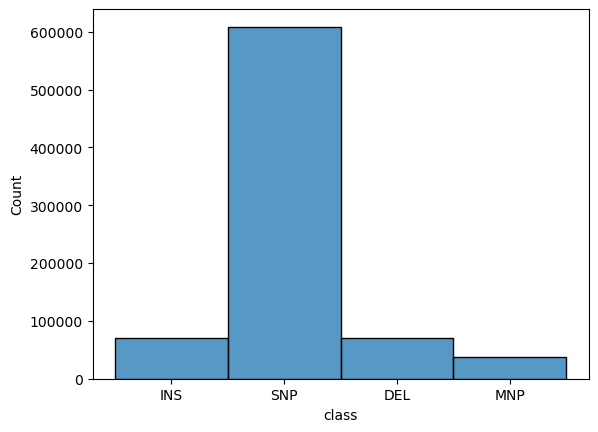

In [42]:
sns.histplot(snarls_top['class'])

In [26]:
snarls_top['class'].value_counts()

class
SNP    608539
INS     71192
DEL     69963
MNP     37051
Name: count, dtype: int64

class
SNP    608539
INS     71192
DEL     69963
MNP     37051
Name: count, dtype: int64

In [ ]:
snarls_all = pd.read_csv('qc_sizes_biallelic.set_02_rep1.deconstruct.all_snarls.tsv', sep = '\t')

In [6]:
snarls['vcf'].unique()

array(['set_02_rep1.deconstruct.top.vcf.gz',
       'set_02_rep1.deconstruct.all_snarls.vcf.gz'], dtype=object)

In [9]:
snarls_top = snarls[snarls['vcf'] == 'set_02_rep1.deconstruct.top.vcf.gz']

In [10]:
snarls_all = snarls[snarls['vcf'] == 'set_02_rep1.deconstruct.all_snarls.vcf.gz']

In [12]:
snarls_top['size_bp'].describe()

count    786745.000000
mean         15.681682
std         464.782422
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      126599.000000
Name: size_bp, dtype: float64

In [15]:
snarls_top

,vcf,chrom,pos,id,alt_index,class,size_bp,is_conflict
0,set_02_rep1.deconstruct.top.vcf.gz,TAIR10#0#Chr1,2,>1>8,1,INS,5919,0
1,set_02_rep1.deconstruct.top.vcf.gz,TAIR10#0#Chr1,892,>8>11,1,SNP,0,0
2,set_02_rep1.deconstruct.top.vcf.gz,TAIR10#0#Chr1,1079,>11>13,1,DEL,3,0
3,set_02_rep1.deconstruct.top.vcf.gz,TAIR10#0#Chr1,6324,>18>20,1,INS,1,0
4,set_02_rep1.deconstruct.top.vcf.gz,TAIR10#0#Chr1,8677,>22>24,1,INS,2,0
...,...,...,...,...,...,...,...,...
786740,set_02_rep1.deconstruct.top.vcf.gz,TAIR10#0#Chr5,26975099,>2349299>2349302,1,SNP,0,0
786741,set_02_rep1.deconstruct.top.vcf.gz,TAIR10#0#Chr5,26975288,>2349302>2349305,1,SNP,0,0
786742,set_02_rep1.deconstruct.top.vcf.gz,TAIR10#0#Chr5,26975377,>2349305>2349308,1,SNP,0,0
786743,set_02_rep1.deconstruct.top.vcf.gz,TAIR10#0#Chr5,26975423,>2349308>2349310,1,DEL,7,0
